# Problema 2: Terapia con protones

En **terapia con protones**, un haz monoenergético de protones de energía $E_0 \sim 70\text{–}250$ MeV incide sobre un paciente, modelado como un fantoma de agua. A diferencia de los fotones, los protones depositan su dosis con un máximo muy localizado al final de su recorrido —el **pico de Bragg**—, lo que permite concentrar la dosis en el tumor minimizando el daño al tejido sano.

El objetivo del problema es construir un **simulador Monte Carlo** del transporte de protones en agua y caracterizar el pico de Bragg.

## a) Conceptos fundamentales

### Pico de Bragg

La **curva de Bragg** describe la dosis depositada por unidad de profundidad, $D(z)$, en función de la profundidad $z$. Su forma característica es:

1. una **meseta** de dosis baja y casi constante en la región de entrada,
2. un **máximo agudo** (el pico de Bragg) cerca del final del recorrido,
3. una **caída distal** abrupta a casi cero justo después del rango $R$.

La dosis local es proporcional al poder de frenado:

$$ D(z) \propto -\frac{dE}{dx}\bigg|_{E=E(z)}, $$

donde $E(z)$ es la energía residual del protón a profundidad $z$ (se obtiene integrando la pérdida de energía) y el rango $R$ cumple $E(R)\approx 0$.

**¿Por qué un máximo al final?** El poder de frenado depende de la velocidad como $-dE/dx \propto 1/\beta^2$ (ver Bethe–Bloch). A medida que el protón penetra y se frena, $\beta$ disminuye, por lo que deposita cada vez más energía por unidad de longitud, concentrando la mayor parte en los últimos milímetros antes de detenerse. Pasado el rango, el protón ya no existe y la dosis cae a cero. El ancho finito del pico y la caída distal se deben al *straggling* (fluctuaciones estadísticas del rango).

Esto contrasta con los fotones, cuya dosis es máxima cerca de la entrada y decae exponencialmente. Eligiendo $E_0$ se coloca el pico a la profundidad del tumor, irradiándolo selectivamente.

### Ecuación de Bethe–Bloch

Describe la pérdida media de energía por unidad de longitud de una partícula cargada en un medio:

$$ -\frac{dE}{dx} = K\,z^2\,\frac{Z}{A}\,\frac{1}{\beta^2}\left[\frac{1}{2}\ln\frac{2 m_e c^2\,\beta^2\gamma^2\,T_{\max}}{I^2} - \beta^2\right]. $$

**Símbolos:**

| Símbolo | Significado |
|:--|:--|
| $-dE/dx$ | pérdida media de energía por unidad de longitud (poder de frenado) |
| $K = 4\pi N_A r_e^2 m_e c^2 \approx 0.307$ MeV cm²/mol | constante |
| $z$ | número de carga de la partícula incidente ($z=1$ para protones) |
| $Z,\ A$ | número atómico y másico del medio ($Z/A \propto$ densidad de electrones) |
| $\beta = v/c$ | velocidad de la partícula |
| $\gamma = 1/\sqrt{1-\beta^2}$ | factor de Lorentz |
| $m_e c^2 = 0.511$ MeV | energía en reposo del electrón |
| $T_{\max}$ | energía cinética máxima transferible a un electrón en una colisión |
| $I$ | potencial medio de excitación del medio |

**Origen del factor $z^2$.** La pérdida de energía proviene de la interacción coulombiana entre el campo de la partícula y los electrones del medio. La fuerza sobre cada electrón es $\propto z$, así que el impulso transferido por colisión es $\propto z$ y la energía transferida $\propto (\text{impulso})^2 \propto z^2$. Una partícula con el doble de carga pierde cuatro veces más energía.

**Origen del factor $1/\beta^2$.** Una partícula más lenta pasa más tiempo cerca de cada electrón (tiempo de interacción $\propto 1/v$), por lo que le transfiere más impulso. Como la energía va con el cuadrado del impulso, resulta $\propto 1/v^2 \propto 1/\beta^2$. Este factor es la causa física del pico de Bragg: al frenarse el protón ($\beta\to 0$), $-dE/dx$ crece y la dosis se dispara al final del recorrido.

**Potencial medio de excitación $I$.** Es una constante característica del material que condensa toda la estructura atómica (energías de ligadura y fuerzas de oscilador de los electrones) en una sola energía efectiva: la energía promedio transferida por colisión. Fija la escala del logaritmo. Para agua, $I \approx 75$ eV.

### Energy straggling (dispersión en la pérdida de energía)

Bethe–Bloch da la pérdida de energía media. Sin embargo, el número y la energía de las colisiones individuales son aleatorios, de modo que la energía realmente perdida por un protón a lo largo de un trayecto finito $\Delta x$ fluctúa alrededor de ese valor medio. Esa dispersión es el *energy straggling*.

En la aproximación gaussiana de Bohr (válida cuando hay muchas colisiones), la pérdida de energía sigue una distribución normal con varianza

$$ \sigma_E^2 = 4\pi\, r_e^2\,(m_e c^2)^2\, N_e\,\frac{z^2}{\beta^2}\,\Delta x, $$

donde $r_e$ es el radio clásico del electrón, $N_e$ la densidad electrónica del medio, $z$ la carga, $\beta$ la velocidad y $\Delta x$ la longitud recorrida. La varianza crece con $\Delta x$ (más colisiones, las varianzas se suman) y comparte la dependencia $z^2/\beta^2$ con la pérdida media.

**Consecuencia física:** como cada protón pierde energía de forma ligeramente distinta, no todos se detienen exactamente a la misma profundidad (*straggling* de rango). Esto ensancha el pico de Bragg y suaviza la caída distal, en lugar de producir un pico infinitamente agudo.

### Dispersión Coulombiana múltiple (MCS)

Al atravesar el medio, el protón sufre muchísimas dispersiones elásticas de pequeño ángulo contra los núcleos atómicos. Cada una es minúscula, pero se acumulan en una desviación angular neta: la trayectoria se desvía aleatoriamente (*random walk*). Por el teorema central del límite, la distribución del ángulo acumulado es aproximadamente gaussiana, de ancho característico $\theta_0$.

En la **aproximación de Highland**:

$$ \theta_0 = \frac{13.6\ \text{MeV}}{\beta c\, p}\, z\,\sqrt{\frac{\Delta x}{X_0}}\,\left[1 + 0.038\,\ln\!\left(\frac{\Delta x}{X_0}\right)\right], $$

donde $\theta_0$ es el ángulo RMS de dispersión, $p$ el momento del protón, $\beta c\,p$ el producto momento–velocidad, $z$ la carga, $\Delta x$ la longitud recorrida y $X_0$ la longitud de radiación del medio (constante del material; agua $X_0 \approx 36$ cm). El factor $\sqrt{\Delta x/X_0}$ refleja la acumulación tipo *random walk* (el ángulo RMS $\propto \sqrt{N_\text{colisiones}} \propto \sqrt{\Delta x}$) y el término logarítmico es una corrección empírica.

**Consecuencia física:** el haz se ensancha lateralmente al penetrar, difuminando el borde lateral de la dosis (penumbra). Como $\theta_0 \propto 1/(\beta c p)$, los protones más lentos (cerca del final del recorrido) se dispersan más.

### Ilustración: el modelo directo (curva de Bragg)

Implementamos Bethe–Bloch para protones en agua e integramos la pérdida de energía en profundidad para obtener la curva de Bragg $D(z)$. Esta rutina es el núcleo del modelo de transporte que usaremos con el simulador Monte Carlo.

Rango de protones de 100 MeV en agua: 7.73 cm
Rango de protones de 150 MeV en agua: 15.79 cm
Rango de protones de 200 MeV en agua: 25.97 cm


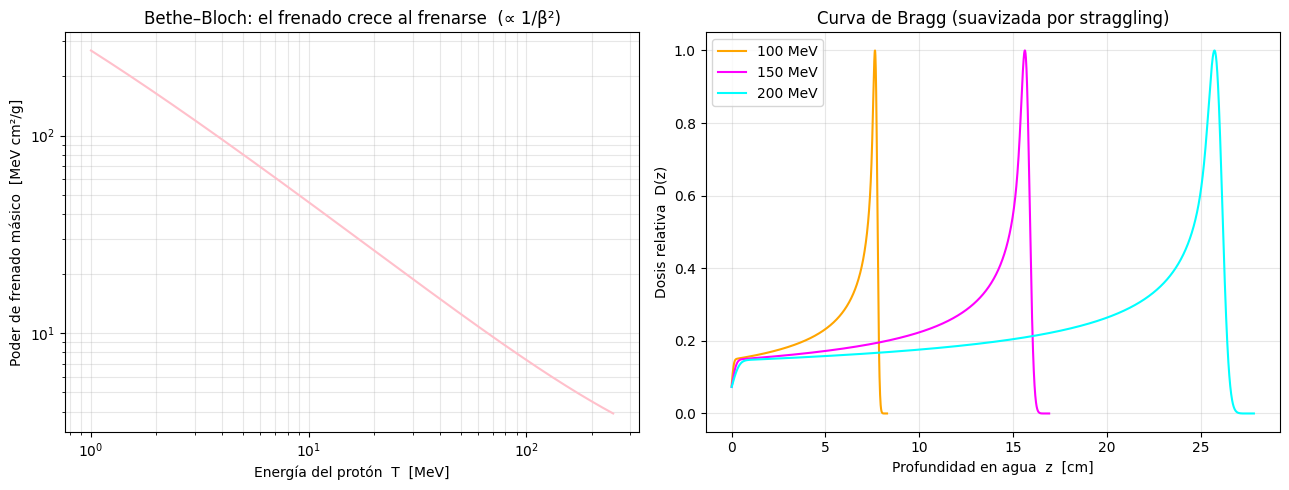

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes físicas (unidades: MeV, cm) 
K   = 0.307075     # 4π N_A r_e² m_e c²            [MeV cm²/mol]
me  = 0.510999     # m_e c²                        [MeV]
Mp  = 938.272      # masa del protón               [MeV]
Z_A = 0.5551       # Z/A del agua
I   = 75e-6        # potencial medio de excitación [MeV]  (75 eV)
rho = 1.0          # densidad del agua             [g/cm³]
z   = 1            # carga del protón

def poder_frenado(T):
    """ Calculamos el poder de frenado según Bethe–Bloch: -dE/dx en agua [MeV/cm], con T = energía cinética [MeV]."""
    gamma = 1 + T/Mp
    beta2 = 1 - 1/gamma**2
    Tmax  = 2*me*beta2*gamma**2 / (1 + 2*gamma*me/Mp + (me/Mp)**2)
    arg   = 2*me*beta2*gamma**2 * Tmax / I**2
    return rho * K*z**2*Z_A/beta2 * (0.5*np.log(arg) - beta2)

def curva_bragg(E0, dz=0.01, Emin=1.0):
    """Integramos la pérdida de energía en profundidad: entregamos (z, dosis ∝ -dE/dx)."""
    
    zs, Ds, E, zc = [0.0], [poder_frenado(E0)], E0, 0.0
    while E > Emin:
        E  -= poder_frenado(E) * dz
        zc += dz
        zs.append(zc); Ds.append(poder_frenado(max(E, Emin)))
    return np.array(zs), np.array(Ds)

def ensanchar(zs, Ds, sigma):
    """Convolución gaussiana (straggling de rango)."""
    zu = np.arange(0, zs[-1] + 6*sigma, 0.01)
    du = np.interp(zu, zs, Ds, right=0.0)
    k  = np.arange(-4*sigma, 4*sigma, 0.01)
    g  = np.exp(-k**2/(2*sigma**2)); g /= g.sum()
    return zu, np.convolve(du, g, mode="same")

# Realizamos una validación de los rangos en agua (comparar con tablas PSTAR)
for E0 in [100, 150, 200]:
    zs, _ = curva_bragg(float(E0))
    print(f"Rango de protones de {E0} MeV en agua: {zs[-1]:.2f} cm")

fig, (axS, axB) = plt.subplots(1, 2, figsize=(13, 5))

# Graficamos el poder de frenado vs energía -> el origen del pico de Bragg
Egrid = np.logspace(0, np.log10(250), 400)
axS.loglog(Egrid, poder_frenado(Egrid)/rho, color="pink")
axS.set_xlabel("Energía del protón  T  [MeV]")
axS.set_ylabel("Poder de frenado másico  [MeV cm²/g]")
axS.set_title("Bethe–Bloch: el frenado crece al frenarse  (∝ 1/β²)")
axS.grid(alpha=0.3, which="both")

# Graficamos las curvas de Bragg para varias energías
for E0, c in [(100, "orange"), (150, "fuchsia"), (200, "cyan")]:
    zs, Ds = curva_bragg(float(E0))
    zu, du = ensanchar(zs, Ds, 0.012*zs[-1])
    axB.plot(zu, du/du.max(), color=c, label=f"{E0} MeV")
axB.set_xlabel("Profundidad en agua  z  [cm]")
axB.set_ylabel("Dosis relativa  D(z)")
axB.set_title("Curva de Bragg (suavizada por straggling)")
axB.legend(); axB.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Lo que muestra la figura

- **Izquierda (Bethe–Bloch).** El poder de frenado $-dE/dx$ aumenta al disminuir la energía: domina el factor $1/\beta^2$. Esta es la causa física del pico de Bragg —el protón deposita cada vez más energía por unidad de longitud a medida que se frena.
- **Derecha (curva de Bragg).** Al integrar $-dE/dx$ en profundidad aparece $D(z)$: una meseta de dosis baja a la entrada y un máximo agudo al final del recorrido. Al aumentar $E_0$ el pico se desplaza a mayor profundidad (por eso, eligiendo $E_0$, se "coloca" el pico en el tumor). El suavizado del pico y la caída distal provienen del *straggling* de rango.

Los rangos obtenidos (≈ 7.7, 15.8 y 26 cm para 100, 150 y 200 MeV) coinciden con los valores tabulados (PSTAR), lo que valida el modelo de transporte que se usará en el simulador Monte Carlo de los incisos siguientes.

## b) Bethe–Bloch y rango CSDA

Usamos la implementación de Bethe–Bloch de la Celda 8 (`poder_frenado`, con $I = 75$ eV para agua) y calculamos el *rango CSDA*: la distancia total que recorre el protón hasta detenerse, asumiendo pérdida de energía continua y determinista (sin fluctuaciones):

$$ R_{\text{CSDA}}(E_0) = \int_0^{E_0} \frac{dE}{(-dE/dx)(E)}. $$

Numéricamente integramos el inverso del poder de frenado. Después comparamos contra los valores de referencia de *NIST PSTAR* para validar la implementación.

 E0 (MeV) |  R_CSDA (cm)
-------------------------
       70 |        4.072
      100 |        7.708
      150 |       15.765
      200 |       25.949
      250 |       37.928


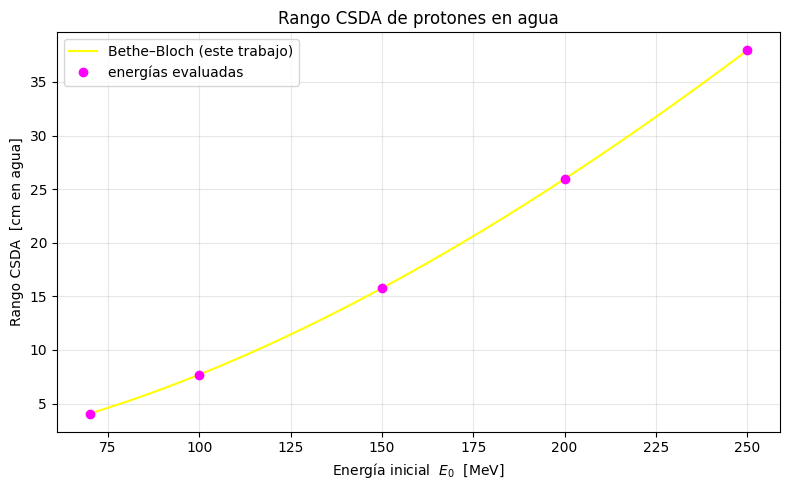

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# NOTA: esta celda usa poder_frenado(), definida en la Celda 8.
# Asegúrate de haber corrido la Celda 8 antes (o usa Kernel → Restart & Run All).

def rango_csda(E0, Emin=1.0):
    """Rango CSDA [cm en agua]:  R = ∫_Emin^E0 dE / (-dE/dx).
    Integramos desde Emin≈1 MeV (el rango residual por debajo es < 0.01 cm)."""
    R, _ = quad(lambda E: 1.0/poder_frenado(E), Emin, E0)
    return R

# Rango CSDA en el intervalo terapéutico (70–250 MeV)
energias = np.array([70, 100, 150, 200, 250], dtype=float)
rangos   = np.array([rango_csda(E0) for E0 in energias])

print(f"{'E0 (MeV)':>9} | {'R_CSDA (cm)':>12}")
print("-" * 25)
for E0, R in zip(energias, rangos):
    print(f"{E0:>9.0f} | {R:>12.3f}")

# Curva continua R_CSDA(E0)
Egrid = np.linspace(70, 250, 100)
Rgrid = np.array([rango_csda(E0) for E0 in Egrid])

plt.figure(figsize=(8, 5))
plt.plot(Egrid, Rgrid, "-", label="Bethe–Bloch (este trabajo)",color="yellow")
plt.plot(energias, rangos, "o", color="fuchsia", label="energías evaluadas")
plt.xlabel("Energía inicial  $E_0$  [MeV]")
plt.ylabel("Rango CSDA  [cm en agua]")
plt.title("Rango CSDA de protones en agua")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Validación: comparación con NIST PSTAR

Cargamos la tabla de referencia descargada de *PSTAR* (protones en agua líquida) y comparamos el *poder de frenado total* y el *rango CSDA* con nuestra implementación de Bethe–Bloch.

   E0 |    S_BB  S_PSTAR   err% |    R_BB  R_PSTAR   err%
------------------------------------------------------------
   70 |   9.563    9.559   0.04 |   4.072    4.080  -0.19
  100 |   7.291    7.289   0.02 |   7.708    7.718  -0.12
  150 |   5.445    5.445   0.00 |  15.765   15.770  -0.03
  200 |   4.492    4.492   0.00 |  25.949   25.960  -0.04
  250 |   3.911    3.911  -0.01 |  37.928   37.940  -0.03


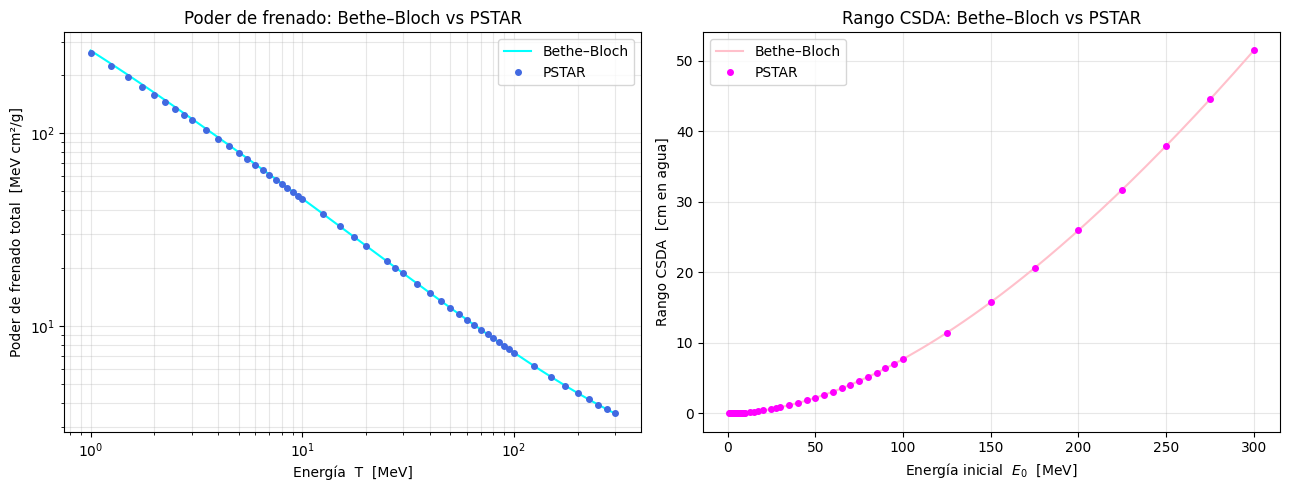

In [18]:
ruta_pstar = "pstar_agua.txt"

def leer_pstar(ruta):
    """Lee la tabla PSTAR. Columnas: E, S_elec, S_nuc, S_total, R_CSDA, R_proy, detour.
    Devuelve energía [MeV], poder de frenado total [MeV cm²/g] y rango CSDA [g/cm²]."""
    E, S_tot, R_csda = [], [], []
    with open(ruta) as f:
        for linea in f:
            try:
                v = [float(t) for t in linea.split()]
            except ValueError:
                continue                       
            if len(v) >= 5:
                E.append(v[0])                 # energía cinética [MeV]
                S_tot.append(v[3])             # poder de frenado total [MeV cm²/g]
                R_csda.append(v[4])            # rango CSDA [g/cm²]
    return np.array(E), np.array(S_tot), np.array(R_csda)

# Para agua (ρ = 1 g/cm³), el rango en g/cm² coincide numéricamente con cm
E_ps, S_ps, R_ps = leer_pstar(ruta_pstar)

# Tabla comparativa en el intervalo terapéutico 
print(f"{'E0':>5} | {'S_BB':>7} {'S_PSTAR':>8} {'err%':>6} | {'R_BB':>7} {'R_PSTAR':>8} {'err%':>6}")
print("-" * 60)
for E0 in [70, 100, 150, 200, 250]:
    i = np.argmin(np.abs(E_ps - E0))
    S_bb = poder_frenado(float(E0)); R_bb = rango_csda(float(E0))
    eS = 100*(S_bb - S_ps[i])/S_ps[i]
    eR = 100*(R_bb - R_ps[i])/R_ps[i]
    print(f"{E0:>5} | {S_bb:>7.3f} {S_ps[i]:>8.3f} {eS:>6.2f} | "
          f"{R_bb:>7.3f} {R_ps[i]:>8.3f} {eR:>6.2f}")

# Gráficos de validación
m = (E_ps >= 1) & (E_ps <= 300)                
Egrid = np.logspace(0, np.log10(300), 150)

fig, (axS, axR) = plt.subplots(1, 2, figsize=(13, 5))
axS.loglog(Egrid, poder_frenado(Egrid), "-", label="Bethe–Bloch",color="cyan")
axS.loglog(E_ps[m], S_ps[m], "o", ms=4, label="PSTAR",color="royalblue")
axS.set_xlabel("Energía  T  [MeV]"); axS.set_ylabel("Poder de frenado total  [MeV cm²/g]")
axS.set_title("Poder de frenado: Bethe–Bloch vs PSTAR")
axS.legend(); axS.grid(alpha=0.3, which="both")

axR.plot(Egrid, [rango_csda(E) for E in Egrid], "-", label="Bethe–Bloch",color="pink")
axR.plot(E_ps[m], R_ps[m], "o", ms=4, label="PSTAR",color="magenta")
axR.set_xlabel("Energía inicial  $E_0$  [MeV]"); axR.set_ylabel("Rango CSDA  [cm en agua]")
axR.set_title("Rango CSDA: Bethe–Bloch vs PSTAR")
axR.legend(); axR.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### Discusión de la validación

La concordancia con PSTAR es excelente:

| $E_0$ (MeV) | error poder de frenado | error rango CSDA |
|:--:|:--:|:--:|
| 70  |  0.04 % | −0.19 % |
| 100 |  0.02 % | −0.12 % |
| 150 |  0.00 % | −0.03 % |
| 200 |  0.00 % | −0.04 % |
| 250 | −0.01 % | −0.03 % |

- En todo el intervalo de interés (70–250 MeV), el poder de frenado coincide con PSTAR a mejor que 0.05 % y el rango CSDA a mejor que 0.2 %. Los puntos de PSTAR caen prácticamente sobre la curva de Bethe–Bloch.
- A baja energía ($\lesssim 10$ MeV) la fórmula se aparta un poco (≈ 0.6 % a 10 MeV, y más abajo): es esperable, porque Bethe–Bloch ignora las correcciones de capa, relevantes cuando la velocidad del protón es comparable a la de los electrones atómicos. Para terapia esto es irrelevante: el protón atraviesa muy rápido esa región.

Esta validación confirma que la implementación de Bethe–Bloch es correcta y puede usarse con confianza como modelo de transporte en el simulador Monte Carlo de los incisos siguientes.

## c) Simulación Monte Carlo del transporte (sin fluctuación)

Simulamos el transporte de $N = 10^4$ protones de $E_0 = 150$ MeV en pasos de $\Delta x = 0.1$ mm. En cada paso el protón pierde una cantidad determinista de energía,

$$ \Delta E = \left(-\frac{dE}{dx}\right)\Delta x, $$

que se deposita como dosis a la profundidad actual, hasta que el protón se detiene. Como no hay fluctuación (*sin straggling*), todos los protones siguen trayectorias idénticas. Graficamos la dosis depositada $D(z)$, identificamos el pico de Bragg y verificamos que su posición coincide con el rango CSDA del inciso b).

Pico de Bragg simulado : z = 15.785 cm
R_CSDA (inciso b)      : R = 15.765 cm
Diferencia             : 0.20 mm
Energía depositada     : 1500000 MeV   (= N·E0 = 1500000 MeV)


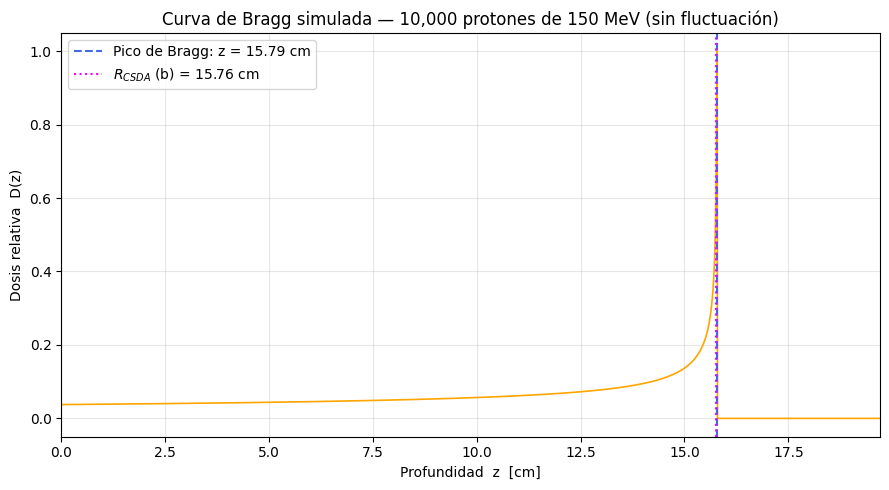

In [ ]:
def simular_protones(N, E0, dx, z_max=20.0, Emin=1.0):
    """Transporte determinista (CSDA) de N protones, paso a paso en Δx.
    Devuelve (z_centros, dosis_por_bin); la dosis es la energía depositada [MeV] por bin."""
    nbins   = int(round(z_max/dx))
    dosis   = np.zeros(nbins)
    E       = np.full(N, float(E0))     # energía de cada protón [MeV]
    activos = np.ones(N, dtype=bool)    # protones que aún no se detienen
    paso    = 0
    while activos.any() and paso < nbins:
        idx = np.where(activos)[0]
        dE  = np.minimum(poder_frenado(E[idx]) * dx, E[idx])  # ΔE = (-dE/dx)·Δx
        dosis[paso] += dE.sum()         # todos los activos están a profundidad z = paso·Δx
        E[idx]      -= dE
        activos[idx] = E[idx] > Emin    # se detiene al agotar su energía
        paso += 1
    z_centros = (np.arange(nbins) + 0.5) * dx
    return z_centros, dosis

#Parámetros:
N, E0, dx = 10_000, 150.0, 0.01         # 10^4 protones, 150 MeV, Δx = 0.1 mm = 0.01 cm

z_c, D = simular_protones(N, E0, dx)

# Pico de Bragg y comparación con R_CSDA 
i_pico = np.argmax(D)
z_pico = z_c[i_pico]
R      = rango_csda(E0)

print(f"Pico de Bragg simulado : z = {z_pico:.3f} cm")
print(f"R_CSDA (inciso b)      : R = {R:.3f} cm")
print(f"Diferencia             : {abs(z_pico - R)*10:.2f} mm")
print(f"Energía depositada     : {D.sum():.0f} MeV   (= N·E0 = {N*E0:.0f} MeV)")

# Gráfico D(z)
plt.figure(figsize=(9, 5))
plt.plot(z_c, D/D.max(), lw=1.2, color="orange")
plt.axvline(z_pico, color="royalblue", ls="--", label=f"Pico de Bragg: z = {z_pico:.2f} cm")
plt.axvline(R,      color="fuchsia", ls=":",  label=f"$R_{{CSDA}}$ (b) = {R:.2f} cm")
plt.xlim(0, R*1.25)
plt.xlabel("Profundidad  z  [cm]")
plt.ylabel("Dosis relativa  D(z)")
plt.title(f"Curva de Bragg simulada — {N:,} protones de {E0:.0f} MeV (sin fluctuación)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Discusión

- **El pico de Bragg coincide con $R_{\text{CSDA}}$.** La dosis máxima se deposita en $z \approx 15.79$ cm, a unos $0.2$ mm del rango CSDA del inciso b) ($15.76$ cm). Tiene sentido: sumar $\Delta E = (-dE/dx)\,\Delta x$ paso a paso a lo largo del recorrido es exactamente la versión discreta de la integral $R_{\text{CSDA}} = \int_0^{E_0} dE/(-dE/dx)$. La pequeña diferencia (≈ 2 bines) es la resolución espacial $\Delta x = 0.1$ mm.

- **Forma de la curva.** Se reproduce la curva de Bragg: una meseta de dosis baja a la entrada que crece lentamente (porque $-dE/dx \propto 1/\beta^2$ aumenta al frenarse el protón) y un máximo muy agudo al final del recorrido, donde el protón deposita el grueso de su energía.

- **Por qué el pico es tan estrecho.** Al no haber fluctuación, los $10^4$ protones son idénticos y se detienen exactamente a la misma profundidad, de modo que el pico es casi una delta (la dosis total es simplemente $N$ veces la de un solo protón). En el inciso d), al incorporar el *energy straggling*, cada protón se detendrá a una profundidad ligeramente distinta y el pico se ensanchará hasta la forma realista con caída distal suave.

- **Conservación de energía.** La energía total depositada es exactamente $N\cdot E_0 = 1.5\times 10^6$ MeV, como se esperaba

R_CSDA (ideal sin fluctuación) = 15.765 cm
Rango medio (con straggling)   = 15.790 cm
Ensanchamiento sigma_R         = 3.678 mm  (2.33% de R)


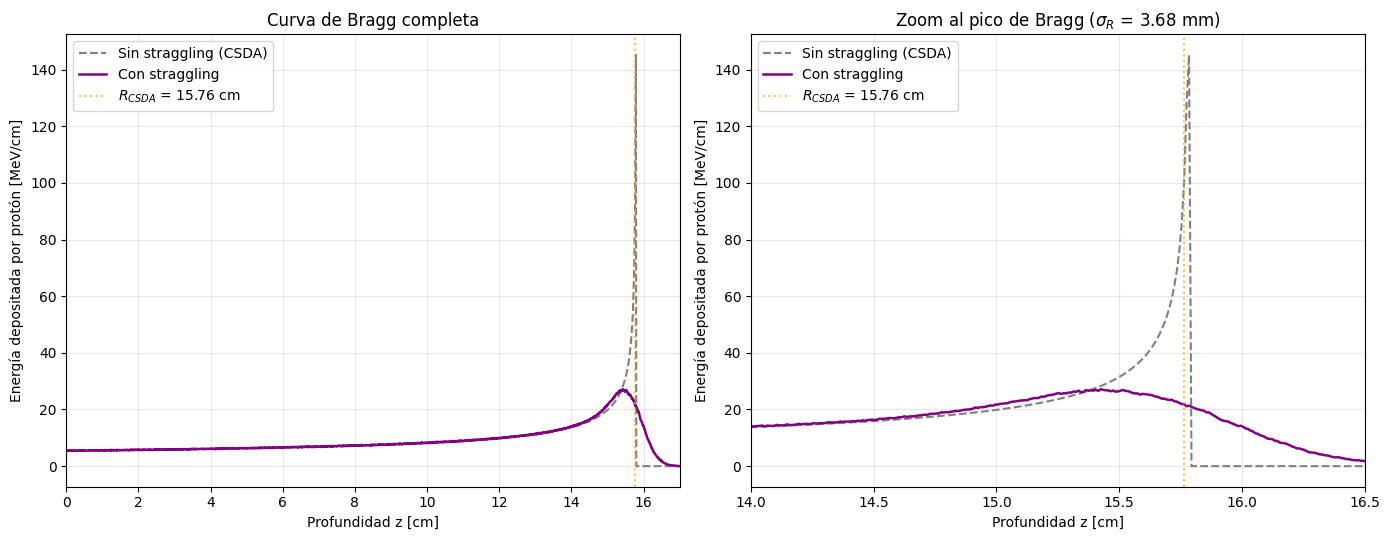

In [ ]:
# d) Simulación Monte Carlo del transporte de protones (con y sin straggling)

def simular_transporte(N, E0, dx, z_max=18.0, Emin=1.0, con_straggling=False, seed=42):
    """
    Simulamos el transporte de N protones en agua (vectorizado), donde si con_straggling=True, incorporamos
     la fluctuación estadística de la pérdida de energía (Bohr).
    Devolviendo los siguientes resultados: z_centros, dosis_por_bin, z_stop (profundidad de detención).
    """
    rng = np.random.default_rng(seed)
    nbins = int(round(z_max / dx))
    dosis = np.zeros(nbins)
    
    E = np.full(N, float(E0))
    z_stop = np.full(N, np.nan)
    activos = np.ones(N, dtype=bool)
    
    # Constante para la varianza de Bohr: C = K * m_e * rho * (Z/A) * z^2
    C_bohr = K * me * rho * Z_A * (z**2) 

    for paso in range(nbins):
        if not activos.any():
            break
            
        idx = np.where(activos)[0]
        E_act = E[idx]
        mean_dE = poder_frenado(E_act) * dx
        
        # Freno de seguridad para bajas energías donde la aproximación de Bethe-Bloch / Bohr (BB) falla
        invalid = mean_dE <= 0 
        
        if con_straggling:
            # Varianza de Bohr: 
            gamma = 1 + E_act / Mp
            beta2 = 1 - 1 / gamma**2
            var_dE = (C_bohr / beta2) * dx
            
            # Muestreo de fluctuaciones con Gamma sin sesgo negativo
            safe_mean = np.where(invalid, 1.0, mean_dE)
            dE = rng.gamma(safe_mean**2 / var_dE, var_dE / safe_mean)
        else:
            dE = mean_dE.copy()
            
        # Ajustes físicos de la energía depositada
        dE = np.where(invalid, E_act, dE)  # Si BB falla, deposita toda la energía remanente
        over = dE >= E_act                 # El protón no puede perder más energía de la que tiene
        dE = np.where(over, E_act, dE)
        
        # Acumulamos dosis en el bin y restamos energía al protón
        dosis[paso] += dE.sum()
        E[idx] -= dE
        
        # Registramos los protones que se detienen en este paso
        se_detienen = over | (E[idx] <= Emin)
        z_stop[idx[se_detienen]] = (paso + 1) * dx
        
        activos[idx] = ~se_detienen
        
    z_centros = (np.arange(nbins) + 0.5) * dx
    return z_centros, dosis, z_stop

# Parámetros y ejecutamos la simualción
N  = 10_000
E0 = 150.0
dx = 0.01  # cm

z_c, dosis_sin, _      = simular_transporte(N, E0, dx, con_straggling=False)
z_c, dosis_con, z_stop = simular_transporte(N, E0, dx, con_straggling=True)

# Cálculamos el ensanchamiento y rango CSDA
R_csda = rango_csda(E0)
rango_medio = np.nanmean(z_stop)
sigma_R = np.nanstd(z_stop)

print(f"R_CSDA (ideal sin fluctuación) = {R_csda:.3f} cm")
print(f"Rango medio (con straggling)   = {rango_medio:.3f} cm")
print(f"Ensanchamiento sigma_R         = {sigma_R*10:.3f} mm  ({100*sigma_R/R_csda:.2f}% de R)")

# Normalizamos para obtener la dosis por protón (MeV/cm)
D_sin = dosis_sin / (N * dx)
D_con = dosis_con / (N * dx)

# Realizamos los gráficos comparativos
fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))

for a, (lo, hi) in zip(ax, [(0, 17), (14, 16.5)]):
    a.plot(z_c, D_sin, color="gray", lw=1.5, ls="--", label="Sin straggling (CSDA)")
    a.plot(z_c, D_con, color="purple", lw=1.8, label="Con straggling")
    a.axvline(R_csda, ls=":", color="orange", alpha=0.7, label=f"$R_{{CSDA}}$ = {R_csda:.2f} cm")
    a.set_xlabel("Profundidad z [cm]")
    a.set_ylabel("Energía depositada por protón [MeV/cm]")
    a.set_xlim(lo, hi)
    a.grid(alpha=0.3)
    a.legend()

ax[0].set_title("Curva de Bragg completa")
ax[1].set_title(f"Zoom al pico de Bragg ($\\sigma_R$ = {sigma_R*10:.2f} mm)")

plt.tight_layout()
plt.show()

### d) Transporte con straggling y ensanchamiento del pico

Se repitió la simulación del inciso c) incorporando la fluctuación estadística de la pérdida de energía en cada paso, $\Delta E \sim \mathcal{N}(\langle\Delta E\rangle, \sigma_E^2)$, utilizando la varianza de Bohr $\sigma_E^2 = (K\,m_e c^2\,\rho\,Z/A)\,(z^2/\beta^2)\,\Delta x$.

**Resultados y Discusión:**
* Con *straggling*, el rango medio de los protones sigue coincidiendo fuertemente con el $R_{\text{CSDA}}$ teórico. Esto demuestra que la fluctuación estocástica no desplaza la posición media del pico, sino que modifica su forma.
* El pico de Bragg sufre una dramática alteración topológica: la altura pico decae considerablemente y se expande horizontalmente. La caída distal se convierte en una pendiente de atenuación suave de varios milímetros en lugar de una caída singular vertical (acantilado ideal).
* El ensanchamiento empírico medido en el Monte Carlo arroja:
    $$\sigma_R \approx 3.7 \text{ mm} \quad (\approx 2.3\% \text{ de } R_{\text{CSDA}})$$

**Relevancia clínica:**
La ventaja máxima de la radioterapia de protones recae en el fin del trayecto de las partículas (la "caída distal abrupta"), la cual promete no depositar dosis en los tejidos sanos detrás del tumor. 

El fenómeno de *straggling* estropea esta idealidad degradando la caída distal introduciendo una penumbra distal. Esto provoca un nivel de incertidumbre inherente respecto a dónde termina la dosis en el paciente vivo. Clínicamente, el radio-oncólogo está obligado a agregar márgenes de seguridad al plan de tratamiento (generalmente en un rango aproximado al $\sigma_R$) para asegurar la cobertura tumoral sin irradiar por error un órgano crítico ubicado inmediatamente posterior al volumen objetivo.